# โจทย์ที่ 2: การจำแนกข่าวด้วย TF-IDF Weighted TextCNN

## Overview

ได้รับข่าวภาษาอังกฤษจาก AG News และต้องจำแนกแต่ละข่าวเป็น 4 หมวด ได้แก่ World, Sports, Business และ Sci/Tech ข้อความดิบมี HTML entities, URL, ตัวเลข, backslash, ช่องว่างไม่สม่ำเสมอ และข่าวซ้ำบางส่วน

ให้ทำความสะอาดข้อความ สร้างคุณลักษณะ TF-IDF และสร้าง TextCNN ด้วย PyTorch โดยสามารถใช้ scikit-learn สำหรับการแบ่งข้อมูล การสร้าง TF-IDF และการวัดผลได้

## Description

ข้อมูลข่าวหลังลบข้อความซ้ำถูกแบ่งจากแหล่งข้อมูลเดียวกันด้วย stratified split ตาม `label` เพื่อให้สัดส่วนทั้ง 4 หมวดใกล้เคียงกันทุกชุด ไฟล์สาธารณะถูกสร้างเป็นไฟล์แยกชัดเจน และ test ไม่มี label

- `train.csv`: ข่าว 95,713 รายการ พร้อม label
- `validation.csv`: ข่าว 12,000 รายการ พร้อม label
- `test.csv`: ข่าว 12,000 รายการ ไม่มี label

คอลัมน์ `label` ใช้ค่า 0 = World, 1 = Sports, 2 = Business และ 3 = Sci/Tech การทำความสะอาด การลบข้อมูลซ้ำ และการแบ่งชุดต้องเกิดก่อน fit vocabulary และ IDF โดย TF-IDF ต้อง fit จากข้อความใน train เท่านั้น

โมเดลรับลำดับ token และค่าน้ำหนัก TF-IDF ของ token ในตำแหน่งเดียวกัน จากนั้นใช้ convolution หลายขนาด kernel เพื่อเรียนรู้รูปแบบ n-gram ก่อนจำแนกหมวดข่าวด้วย PyTorch

## Public Data

โครงสร้างไฟล์ใน `data/public`:

```text
train.csv
validation.csv
test.csv
```

`train.csv` และ `validation.csv` มีคอลัมน์ `id`, `text`, `label` ส่วน `test.csv` มีเพียง `id`, `text` ลำดับแถวของ `test.csv` ตรงกับ id ที่ใช้ใน submission

## Evaluation

ใช้ Accuracy และ Macro-F1 โดย Macro-F1 ให้น้ำหนักแต่ละคลาสเท่ากัน

```text
Macro-F1 = mean(F1_World, F1_Sports, F1_Business, F1_SciTech)
```

ให้ใช้ validation สำหรับเลือกขั้นตอน clean text, vocabulary size, sequence length, kernel sizes, dropout และ checkpoint โดยห้ามใช้คำตอบของ test ระหว่างพัฒนาโมเดล

## Submission File

ส่งไฟล์ `submission_nlp.csv` จำนวน 12,000 แถว

```csv
id,label
17,2
483,0
921,3
```

- `id`: id จาก `test.csv`
- `label`: คลาสที่ทำนาย ต้องเป็น 0, 1, 2 หรือ 3


In [1]:
import re, html, random, time, warnings
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(max(1, min(8, torch.get_num_threads())))
print("device:", device)
print("torch:", torch.__version__)

device: cpu
torch: 2.14.0+cpu


In [2]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
source_file = data_dir / "ag_news_train.parquet"
url = "https://huggingface.co/api/datasets/fancyzhx/ag_news/parquet/default/train/0.parquet"
if not source_file.exists():
    pd.read_parquet(url).to_parquet(source_file, index=False)
train_all = pd.read_parquet(source_file).reset_index(drop=True)
train_all["label"] = train_all.label.astype(int)
train_all.insert(0, "id", np.arange(len(train_all)))
if "text" not in train_all.columns:
    train_all["text"] = train_all.title.fillna("") + " " + train_all.description.fillna("")
train_all = train_all[["id", "text", "label"]]
print("downloaded rows:", len(train_all))
print(train_all.label.value_counts().sort_index())
train_all.head()


downloaded rows: 120000
label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


,id,text,label
0,0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,4,"Oil prices soar to all-time record, posing new...",2


In [3]:
def clean_text(text):
    text = html.unescape(str(text))
    text = text.replace("\\", " ")
    text = re.sub(r"^(reuters|ap|afp|usatoday\.com|pc world|techweb)\s*[-:]\s*", " ", text, flags=re.I)
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " <url> ", text)
    text = re.sub(r"\b\d+(?:[.,]\d+)*\b", " <num> ", text)
    text = re.sub(r"[^a-z<>']+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
train_all["clean"] = train_all.text.map(clean_text)
before = len(train_all)
train_all = train_all.drop_duplicates("clean").reset_index(drop=True)
print("removed duplicates:", before - len(train_all))
print("rows after deduplication:", len(train_all))
lengths = train_all.clean.str.split().str.len()
display(lengths.describe(percentiles=[.5, .9, .95, .99]).to_frame("tokens").round(1))
display(train_all[["text", "clean", "label"]].head(4))


removed duplicates: 287
rows after deduplication: 119713


,tokens
count,119713.0
mean,39.0
std,10.5
min,10.0
50%,38.0
90%,50.0
95%,55.0
99%,72.0
max,177.0


,text,clean,label
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks' outlook reuters ...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...,2


In [4]:
development_df, private_test_df = train_test_split(train_all, test_size=12000, random_state=SEED, stratify=train_all.label)
train_df, val_df = train_test_split(development_df, test_size=12000, random_state=SEED + 1, stratify=development_df.label)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
private_test_df = private_test_df.reset_index(drop=True)
private_test_labels = private_test_df.label.to_numpy(np.int64)
public_dir = data_dir / "public"
public_dir.mkdir(exist_ok=True)
train_df[["id", "text", "label"]].to_csv(public_dir / "train.csv", index=False)
val_df[["id", "text", "label"]].to_csv(public_dir / "validation.csv", index=False)
private_test_df[["id", "text"]].to_csv(public_dir / "test.csv", index=False)
train_df = pd.read_csv(public_dir / "train.csv")
val_df = pd.read_csv(public_dir / "validation.csv")
test_df = pd.read_csv(public_dir / "test.csv")
for frame in [train_df, val_df, test_df]:
    frame["clean"] = frame.text.map(clean_text)
print("public files:", sorted(path.name for path in public_dir.iterdir()))
print("train:", train_df.shape, train_df.columns.tolist())
print("validation:", val_df.shape, val_df.columns.tolist())
print("test:", test_df.shape, test_df.columns.tolist())
print("test label present:", "label" in test_df.columns)
split_distribution = pd.concat({"train": train_df.label.value_counts(normalize=True), "validation": val_df.label.value_counts(normalize=True)}, axis=1)
split_distribution["test_private_check"] = pd.Series(private_test_labels).value_counts(normalize=True)
display(split_distribution.sort_index().round(4))
vectorizer = TfidfVectorizer(max_features=25000, min_df=3, max_df=0.98, sublinear_tf=True, norm="l2", token_pattern=r"(?u)\b[a-z][a-z']+\b|<num>|<url>")
vectorizer.fit(train_df.clean)
feature_names = vectorizer.get_feature_names_out()
idf = vectorizer.idf_
print("vocabulary:", len(feature_names))
print("lowest IDF:", feature_names[np.argsort(idf)[:15]].tolist())
print("highest IDF:", feature_names[np.argsort(idf)[-15:]].tolist())


public files: ['test.csv', 'train.csv', 'validation.csv']
train: (95713, 4) ['id', 'text', 'label', 'clean']
validation: (12000, 4) ['id', 'text', 'label', 'clean']
test: (12000, 3) ['id', 'text', 'clean']
test label present: False


,train,validation,test_private_check
label,,,
0,0.2503,0.2502,0.2502
1,0.2503,0.2503,0.2503
2,0.2499,0.2498,0.2498
3,0.2495,0.2496,0.2496


vocabulary: 25000
lowest IDF: ['the', 'to', '<num>', 'of', 'in', 'and', 'on', 'for', 'that', 'with', 'as', 'at', 'said', 'is', 'by']
highest IDF: ['dowie', 'enceladus', 'steelcase', 'dresser', 'dtm', 'ellinger', 'eln', 'dulko', 'stimulative', 'zell', 'dyer', 'dyncorp', 'edocs', 'egan', 'zy']


In [5]:
sample_rows = vectorizer.transform(train_df.clean.iloc[:4])
for i in range(4):
    row = sample_rows.getrow(i)
    order = np.argsort(row.data)[-8:][::-1]
    words = [(feature_names[row.indices[j]], round(float(row.data[j]), 3)) for j in order]
    print(i, words)

0 [('egypt', 0.318), ('assemble', 0.263), ('coordinated', 0.249), ('occurred', 0.222), ('resorts', 0.222), ('identify', 0.219), ('slowed', 0.208), ('or', 0.205)]
1 [('snooping', 0.295), ('unspecified', 0.279), ('copyrighted', 0.258), ('mpaa', 0.257), ('motion', 0.215), ('movies', 0.212), ('picture', 0.211), ('lawsuits', 0.206)]
2 [('jeter', 0.415), ('elbow', 0.413), ('yankees', 0.28), ('bruised', 0.236), ('hit', 0.235), ('derek', 0.227), ('indians', 0.215), ('ok', 0.203)]
3 [('allawi', 0.316), ('kidnapped', 0.281), ('family', 0.268), ('members', 0.262), ("allawi's", 0.261), ('rebellious', 0.259), ('cousin', 0.23), ('meanwhile', 0.218)]


In [6]:
token_pattern = re.compile(r"\b[a-z][a-z']+\b|<num>|<url>")
vocabulary = vectorizer.vocabulary_
MAX_LEN = 80
def encode_frame(frame, labels=None):
    n = len(frame)
    ids = np.zeros((n, MAX_LEN), dtype=np.int32)
    weights = np.zeros((n, MAX_LEN), dtype=np.float32)
    matrix = vectorizer.transform(frame.clean)
    for i, text in enumerate(frame.clean):
        tokens = token_pattern.findall(text)[:MAX_LEN]
        row = matrix.getrow(i)
        score = dict(zip(row.indices.tolist(), row.data.tolist()))
        for j, token in enumerate(tokens):
            k = vocabulary.get(token)
            if k is not None:
                ids[i, j] = k + 2
                weights[i, j] = score.get(k, 0.0)
            else:
                ids[i, j] = 1
    if labels is None:
        return ids, weights
    return ids, weights, np.asarray(labels, dtype=np.int64)
train_ids, train_weights, train_labels = encode_frame(train_df, train_df.label)
val_ids, val_weights, val_labels = encode_frame(val_df, val_df.label)
test_ids, test_weights = encode_frame(test_df)
print(train_ids.shape, train_weights.shape, train_labels.shape)
print(val_ids.shape, val_weights.shape, val_labels.shape)
print(test_ids.shape, test_weights.shape)


(95713, 80) (95713, 80) (95713,)
(12000, 80) (12000, 80) (12000,)
(12000, 80) (12000, 80)


In [7]:
class NewsDataset(Dataset):
    def __init__(self, ids, weights, labels=None, augment=False):
        self.ids = torch.from_numpy(ids)
        self.weights = torch.from_numpy(weights)
        self.labels = None if labels is None else torch.from_numpy(labels)
        self.augment = augment
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, i):
        ids = self.ids[i].long()
        weights = self.weights[i].float()
        if self.augment:
            mask = (torch.rand_like(weights) < 0.04) & (ids > 1)
            ids = ids.masked_fill(mask, 0)
            weights = weights.masked_fill(mask, 0)
        if self.labels is None:
            return ids, weights
        return ids, weights, self.labels[i]
train_loader = DataLoader(NewsDataset(train_ids, train_weights, train_labels, True), batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(NewsDataset(val_ids, val_weights, val_labels), batch_size=512, shuffle=False, num_workers=0)
test_loader = DataLoader(NewsDataset(test_ids, test_weights), batch_size=512, shuffle=False, num_workers=0)
print("batches:", len(train_loader), len(val_loader), len(test_loader))


batches: 374 24 24


In [8]:
class TfidfTextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=72, filters=80, kernels=(3, 4, 5), classes=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(embedding_dim, filters, k) for k in kernels])
        self.norm = nn.LayerNorm(filters * len(kernels))
        self.classifier = nn.Sequential(nn.Dropout(0.35), nn.Linear(filters * len(kernels), classes))
    def forward(self, ids, weights):
        x = self.embedding(ids) * (1.0 + 3.0 * weights.unsqueeze(-1))
        x = x.transpose(1, 2)
        pooled = [F.relu(conv(x)).amax(dim=2) for conv in self.convs]
        return self.classifier(self.norm(torch.cat(pooled, dim=1)))
model = TfidfTextCNN(len(vocabulary) + 2).to(device)
ids_b, weights_b, labels_b = next(iter(train_loader))
print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))
print("forward:", tuple(model(ids_b[:4].to(device), weights_b[:4].to(device)).shape))


TfidfTextCNN(
  (embedding): Embedding(25002, 72, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(72, 80, kernel_size=(3,), stride=(1,))
    (1): Conv1d(72, 80, kernel_size=(4,), stride=(1,))
    (2): Conv1d(72, 80, kernel_size=(5,), stride=(1,))
  )
  (norm): LayerNorm((240,), eps=1e-05, elementwise_affine=True, bias=True)
  (classifier): Sequential(
    (0): Dropout(p=0.35, inplace=False)
    (1): Linear(in_features=240, out_features=4, bias=True)
  )
)
parameters: 1870948
forward: (4, 4)


In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, eta_min=2e-4)
history = []
best_acc = 0.0
best_state = None
for epoch in range(1, 6):
    model.train()
    running = 0.0
    correct = 0
    seen = 0
    for ids, weights, labels in train_loader:
        ids, weights, labels = ids.to(device), weights.to(device), labels.to(device)
        logits = model(ids, weights)
        loss = F.cross_entropy(logits, labels, label_smoothing=0.04)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        running += loss.item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        seen += len(labels)
    model.eval()
    vp, vt = [], []
    with torch.no_grad():
        for ids, weights, labels in val_loader:
            logits = model(ids.to(device), weights.to(device))
            vp.append(logits.argmax(1).cpu())
            vt.append(labels)
    vp = torch.cat(vp).numpy()
    vt = torch.cat(vt).numpy()
    val_acc = accuracy_score(vt, vp)
    val_f1 = f1_score(vt, vp, average="macro")
    train_loss = running / seen
    train_acc = correct / seen
    history.append((epoch, train_loss, train_acc, val_acc, val_f1))
    if val_acc > best_acc:
        best_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"epoch={epoch} loss={train_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}")
    scheduler.step()
model.load_state_dict(best_state)
print("best validation accuracy:", round(best_acc, 4))

epoch=1 loss=0.7088 train_acc=0.7658 val_acc=0.8662 val_f1=0.8663


epoch=2 loss=0.4676 train_acc=0.8844 val_acc=0.8882 val_f1=0.8880


epoch=3 loss=0.3954 train_acc=0.9159 val_acc=0.8968 val_f1=0.8968


epoch=4 loss=0.3531 train_acc=0.9358 val_acc=0.8998 val_f1=0.8996


epoch=5 loss=0.3256 train_acc=0.9485 val_acc=0.9006 val_f1=0.9004
best validation accuracy: 0.9006


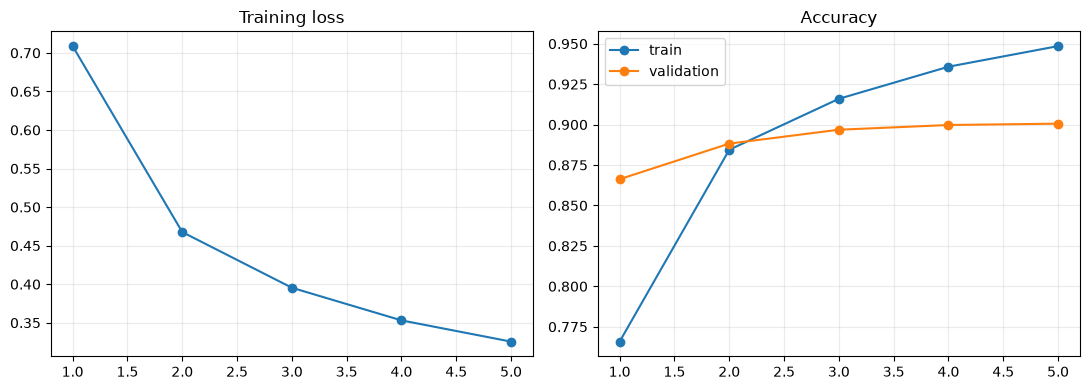

In [10]:
hist = pd.DataFrame(history, columns=["epoch", "loss", "train_accuracy", "validation_accuracy", "validation_macro_f1"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist.epoch, hist.loss, marker="o")
axes[0].set_title("Training loss")
axes[1].plot(hist.epoch, hist.train_accuracy, marker="o", label="train")
axes[1].plot(hist.epoch, hist.validation_accuracy, marker="o", label="validation")
axes[1].legend()
axes[1].set_title("Accuracy")
for ax in axes:
    ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

In [11]:
model.eval()
test_pred, test_prob = [], []
with torch.no_grad():
    for ids, weights in test_loader:
        logits = model(ids.to(device), weights.to(device))
        test_pred.append(logits.argmax(1).cpu())
        test_prob.append(logits.softmax(1).amax(1).cpu())
test_pred = torch.cat(test_pred).numpy()
test_prob = torch.cat(test_prob).numpy()
print("test predictions:", test_pred.shape)
print(pd.Series(test_pred).value_counts().sort_index())


test predictions: (12000,)
0    2947
1    3065
2    2979
3    3009
Name: count, dtype: int64


In [12]:
submission = pd.DataFrame({"id": test_df.id.to_numpy(), "label": test_pred.astype(int)})
submission.to_csv("submission_nlp.csv", index=False)
print("public test columns:", test_df.columns.tolist())
print("submission:", submission.shape)
print(submission.label.value_counts().sort_index())
submission.head(10)


public test columns: ['id', 'text', 'clean']
submission: (12000, 2)
label
0    2947
1    3065
2    2979
3    3009
Name: count, dtype: int64


,id,label
0,52107,1
1,3222,1
2,102019,1
3,15651,2
4,18680,0
5,2993,1
6,23353,3
7,95465,1
8,54768,2
9,92212,0


private test accuracy: 0.8978
private test macro F1: 0.8976
              precision    recall  f1-score   support

       World     0.9046    0.8878    0.8961      3003
      Sports     0.9445    0.9637    0.9540      3004
    Business     0.8711    0.8656    0.8683      2998
    Sci/Tech     0.8701    0.8741    0.8721      2995

    accuracy                         0.8978     12000
   macro avg     0.8976    0.8978    0.8976     12000
weighted avg     0.8976    0.8978    0.8977     12000



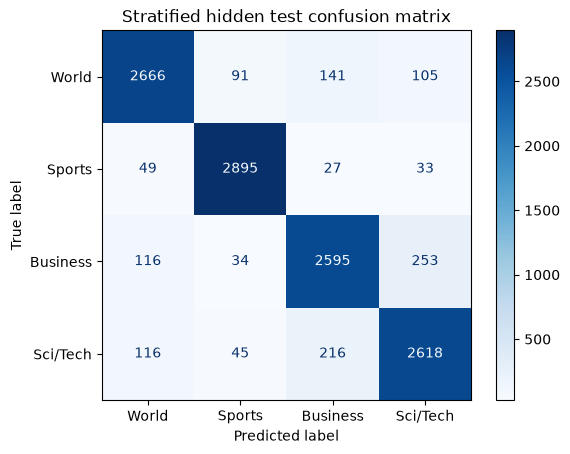

In [13]:
class_names = ["World", "Sports", "Business", "Sci/Tech"]
print("private test accuracy:", round(accuracy_score(private_test_labels, test_pred), 4))
print("private test macro F1:", round(f1_score(private_test_labels, test_pred, average="macro"), 4))
print(classification_report(private_test_labels, test_pred, target_names=class_names, digits=4))
cm = confusion_matrix(private_test_labels, test_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues", values_format="d")
plt.title("Stratified hidden test confusion matrix")
plt.show()


In [14]:
errors = test_df.loc[test_pred != private_test_labels, ["text"]].copy()
errors["label"] = private_test_labels[test_pred != private_test_labels]
errors["prediction"] = test_pred[test_pred != private_test_labels]
errors["confidence"] = test_prob[test_pred != private_test_labels]
errors["true_name"] = errors.label.map(dict(enumerate(class_names)))
errors["predicted_name"] = errors.prediction.map(dict(enumerate(class_names)))
errors.sort_values("confidence", ascending=False)[["true_name", "predicted_name", "confidence", "text"]].head(12)


,true_name,predicted_name,confidence,text
7460,World,Business,0.996618,Riggs National Subject of Investigation Riggs ...
8074,Business,Sci/Tech,0.996337,IBM Puts Spotlight On Entry-Level Linux Server...
2128,World,Sci/Tech,0.995652,Space Capsule Crashes in Utah The Genesis spac...
9058,World,Sports,0.995280,Baseball: Boston win World Series Boston clinc...
1709,World,Business,0.995259,Greenspan warns over US deficit Federal Reserv...
11230,Sci/Tech,Business,0.995089,Novell Turns A Q3 Profit Novell Inc. is report...
3347,World,Sports,0.994953,Golf: Woods reveals Cup ambition Tiger Woods w...
2743,World,Sports,0.994861,Baseball Returns to Washington as Expos Move F...
6997,Sci/Tech,Sports,0.994835,Lightning Strike Injures 40 on Texas Field (AP...
11392,World,Business,0.994481,Wal-Mart Lowers Sales Forecast for August LITT...


In [15]:
def noisy_text(text, rate=0.12):
    tokens = text.split()
    rng = np.random.default_rng(abs(hash(text)) % (2**32))
    kept = [token for token in tokens if rng.random() > rate]
    return " ".join(kept)
noisy_df = test_df.copy()
noisy_df["clean"] = noisy_df.clean.map(noisy_text)
noisy_ids, noisy_weights = encode_frame(noisy_df)
noisy_loader = DataLoader(NewsDataset(noisy_ids, noisy_weights), batch_size=512)
noisy_pred = []
with torch.no_grad():
    for ids, weights in noisy_loader:
        noisy_pred.append(model(ids.to(device), weights.to(device)).argmax(1).cpu())
noisy_pred = torch.cat(noisy_pred).numpy()
print("clean accuracy:", round(accuracy_score(private_test_labels, test_pred), 4))
print("word-drop 12% accuracy:", round(accuracy_score(private_test_labels, noisy_pred), 4))
print("prediction agreement:", round(np.mean(test_pred == noisy_pred), 4))


clean accuracy: 0.8978
word-drop 12% accuracy: 0.8867
prediction agreement: 0.9465
